# EDSS Observations

This notebook explores the Expanded Disability Status Scale (EDSS, code `273554001`) observations in the corrected Synthea MS dataset at `data/corrected`.

1. Distribution of EDSS values across all observations.
2. Individual EDSS trajectories (EDSS vs. year) for 10 representative patients.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA_DIR = Path("../data/csv")
EDSS_CODE = "273554001"

# Categorical palette (fixed order, colorblind-safe, 8 hues max)
BLUE = "#2a78d6"
SERIES_COLORS = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
]
# With more series than hues, repeat the palette with a dashed linestyle so
# lines stay distinguishable via a second (non-color) channel.
SERIES_LINESTYLES = ["-"] * len(SERIES_COLORS) + ["--"] * len(SERIES_COLORS)

plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"
plt.rcParams["xtick.color"] = "#52514e"
plt.rcParams["ytick.color"] = "#52514e"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
observations = pd.read_csv(DATA_DIR / "observations.csv", parse_dates=["DATE"])

edss = observations[observations["CODE"].astype(str) == EDSS_CODE].copy()
edss["VALUE"] = pd.to_numeric(edss["VALUE"], errors="coerce")
edss["YEAR"] = edss["DATE"].dt.year + (edss["DATE"].dt.dayofyear - 1) / 365.25

print(f"EDSS observations: {len(edss)}")
print(f"Patients with EDSS observations: {edss['PATIENT'].nunique()}")
edss.head()

EDSS observations: 2874
Patients with EDSS observations: 406


,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE,YEAR
16,2010-05-16 14:49:08+00:00,98cf5a0c-d567-51a1-9cb5-a91e6d011996,98cf5a0c-d567-51a1-4f94-491dbffd8213,exam,273554001,Expanded Disability Status Scale (EDSS),2.0,NaN,text,2010.369610
17,2024-08-24 06:47:59+00:00,7f9a80a4-6754-a0d3-58d9-1068743ad932,7f9a80a4-6754-a0d3-453a-a4ae0cbdc7c6,exam,273554001,Expanded Disability Status Scale (EDSS),2.0,NaN,text,2024.646133
18,2025-07-09 17:57:39+00:00,33bf0629-1316-cf72-f68d-fc174859fef5,33bf0629-1316-cf72-9424-7a4d959c821b,exam,273554001,Expanded Disability Status Scale (EDSS),2.5,NaN,text,2025.517454
19,2015-11-23 07:18:36+00:00,1a4f7487-d2e6-408c-44a8-ca456c6e38bb,1a4f7487-d2e6-408c-ac45-5451312afc01,exam,273554001,Expanded Disability Status Scale (EDSS),3.0,NaN,text,2015.892539
20,2024-11-22 22:26:44+00:00,595f9fb9-fcf0-e5bc-239a-e86a96db6211,595f9fb9-fcf0-e5bc-1cf0-d4ad41027775,exam,273554001,Expanded Disability Status Scale (EDSS),4.0,NaN,text,2024.892539


## 1. Distribution of EDSS

EDSS is scored on `[0, 10]` in `0.5` steps, so it's an ordinal scale rather than a continuous one. A bar chart over the observed steps (rather than a binned histogram) respects that.

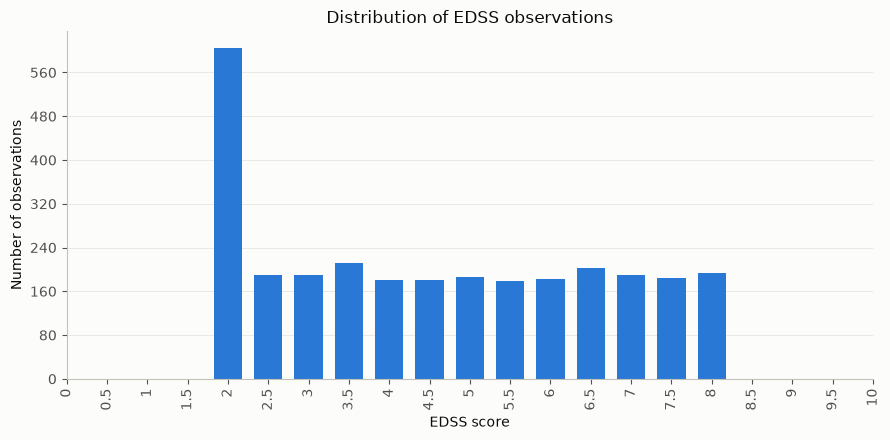

In [3]:
value_counts = edss["VALUE"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(value_counts.index, value_counts.values, width=0.35, color=BLUE)

ax.set_title("Distribution of EDSS observations")
ax.set_xlabel("EDSS score")
ax.set_ylabel("Number of observations")
ax.set_xticks([x / 2 for x in range(0, 21)])
ax.set_xticklabels([f"{x/2:g}" for x in range(0, 21)], rotation=90)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", linewidth=0.5)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

In [4]:
edss["VALUE"].describe()

count    2874.000000
mean        4.561935
std         2.032967
min         2.000000
25%         2.500000
50%         4.500000
75%         6.500000
max         8.000000
Name: VALUE, dtype: float64

## 2. Individual EDSS trajectories

To see how disability progresses over time for individual patients, we plot EDSS against the year of observation. We pick the 10 patients with the most EDSS readings, so each trajectory has more than a single point.

In [5]:
patients_by_count = edss["PATIENT"].value_counts()
top_patients = patients_by_count.head(10).index.tolist()

patients_by_count.head(20)

PATIENT
08f0dfbd-120a-b5c0-17a1-017ae4c60bcd    22
62e7350d-5b1e-7eac-5e0f-a25c355deba6    21
f0398dd7-e2ec-b380-4bba-60dc7f17ef9b    20
9878952d-13df-5a60-cd5e-9ee899b8d46c    20
a40b625c-13de-fca0-2ff5-b5a6d1773b18    19
82e8ac70-5e83-d44e-30e8-d8ccb346178f    19
f705f6bc-5ba0-92bb-9fed-0d81c5508b43    18
db44eb5c-9ef3-4693-9d75-3e873fe94a4f    18
7bbaa47e-d029-bf4f-3237-ddd955c0a584    17
8cb3b0ae-e4dc-5813-e102-37058bfa838d    17
8279178d-e14b-b9ba-4bd6-0f2cf933b5d2    17
a352c401-3aa9-849c-9401-9eba43e5f846    17
55320a25-203b-9b59-88cc-c6b4d6662a3c    17
b0f6d7e6-8c25-2a8d-699d-8767d40c29f9    16
6a874fc2-db50-3604-3f17-104b9e719b54    16
235ae5d6-0e9b-caae-d582-1a49e96bb7b8    16
71999df2-6994-f040-6136-ec4fa5d5ebbb    16
824cc1b4-6bd4-21f1-a559-e74f3a37260f    16
d9896ece-8362-1da9-0377-0d04938a91b0    15
3d400f3f-2a3c-360b-62a8-32c5d56df57d    15
Name: count, dtype: int64

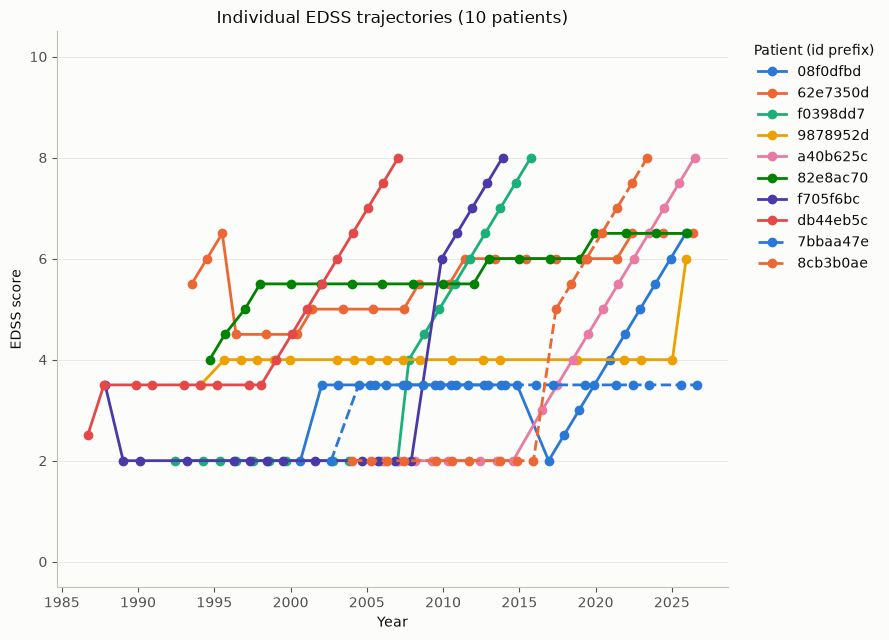

In [6]:
fig, ax = plt.subplots(figsize=(9, 6.5))

for color, linestyle, patient_id in zip(SERIES_COLORS * 2, SERIES_LINESTYLES, top_patients):
    trajectory = edss[edss["PATIENT"] == patient_id].sort_values("YEAR")
    label = patient_id[:8]
    ax.plot(
        trajectory["YEAR"], trajectory["VALUE"],
        marker="o", markersize=6, linewidth=2,
        color=color, linestyle=linestyle, label=label,
    )

ax.set_title("Individual EDSS trajectories (10 patients)")
ax.set_xlabel("Year")
ax.set_ylabel("EDSS score")
ax.set_ylim(-0.5, 10.5)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", linewidth=0.5)
ax.set_axisbelow(True)
ax.legend(title="Patient (id prefix)", loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

fig.tight_layout()
plt.show()